In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import seaborn as sns 
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

In [83]:
df = pd.read_csv("true_value_customer_deals_v1.csv")
df

,retailer,product_id,product_name,brand,size,current_price,original_price,saving_amount,unit_price_text,promo_flag,...,category_median_discount,category_max_discount,category_q25_discount,category_q75_discount,base_score,category_relative_score,true_value_score,discount_class,saving_amount_capped,discount_class_v2
0,Coles,8.781518e+06,Regular Pork Mince,Coles,500g,5.50,6.50,1.00,$11.00/ 1kg,0.0,...,13.64,39.39,10.3950,18.6050,12.50,10,22.50,OK Discount,1.00,OK Discount
1,Coles,1.546564e+06,Tasmanian Salmon Portions Skin On 4 Pack,Coles,460g,17.50,19.50,2.00,$38.04/ 1kg,0.0,...,13.64,39.39,10.3950,18.6050,8.61,0,8.61,OK Discount,2.00,OK Discount
2,Coles,3.292300e+06,Lamb Loin Chops Bulk,Coles,approx. 890g,23.14,29.37,6.23,$26.00/ 1kg,0.0,...,13.64,39.39,10.3950,18.6050,18.21,15,33.21,Good Discount,6.23,Good Discount
3,Coles,3.035293e+06,Pork Spare Ribs,Coles,approx. 950g,18.05,20.90,2.85,$19.00/ 1kg,0.0,...,13.64,39.39,10.3950,18.6050,11.48,10,21.48,OK Discount,2.85,OK Discount
4,Coles,3.745878e+06,RSPCA Approved Chicken Kebabs Honey & Soy,Coles,750g,10.00,11.50,1.50,$13.33/ 1kg,0.0,...,15.48,33.33,11.4575,22.2200,10.73,5,15.73,OK Discount,1.50,OK Discount
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,IGA,1.900000e+11,James Squire 150 Lashes Pale Ale Can Wrap,James Squire,NaN,19.00,19.99,0.99,$3.17 each,NaN,...,13.30,48.00,9.0100,19.9525,4.16,0,4.16,OK Discount,0.99,OK Discount
8993,IGA,5.661100e+04,Carlton Dry Bottles,Carlton,NaN,59.00,66.99,7.99,$2.46 each,NaN,...,13.30,48.00,9.0100,19.9525,11.14,5,16.14,OK Discount,7.99,OK Discount
8994,IGA,1.900000e+11,Jameson Irish Whiskey Smooth Dry & Lime,Jameson,NaN,134.99,137.00,2.01,$5.62 each,NaN,...,13.30,48.00,9.0100,19.9525,1.58,0,1.58,OK Discount,2.01,OK Discount
8995,IGA,1.692500e+04,Rockstar Punched Energy & Guava Drink,Rockstar,NaN,3.30,3.95,0.65,$0.66/100ml,NaN,...,30.00,50.65,18.8700,40.0000,13.30,0,13.30,OK Discount,0.65,OK Discount


In [42]:
df["discount_class_v2"].value_counts()

discount_class_v2
Good Discount              3182
OK Discount                3050
Excellent Discount         2761
DiscountMate Recommends       4
Name: count, dtype: int64

In [4]:
user_df = pd.read_csv("synthetic_users_20260831.csv")
user_df

,sessions_count,avg_engagement_time_sec,pageviews_per_session,compare_ratio,specials_ratio,mylists_ratio,category_browse_ratio,product_detail_ratio,unique_pages_visited,browsing_entropy,days_since_first_visit,days_since_last_activity,user_pseudo_id,reporting_window_start,reporting_window_end,is_included_in_run
0,1,15.39,2.67,0.0000,0.0000,0.0000,0.0382,0.0255,3,0.0112,NaN,10,syn_20260831_000001,2026-08-17,2026-08-30,1
1,5,194.98,9.85,0.0618,0.0694,0.2750,0.1673,0.0697,19,0.7500,14.0,1,syn_20260831_000002,2026-08-17,2026-08-30,1
2,3,163.32,5.57,0.0982,0.0104,0.1000,0.1514,0.3000,8,0.4323,NaN,6,syn_20260831_000003,2026-08-17,2026-08-30,1
3,4,97.80,6.74,0.3371,0.3073,0.0233,0.0500,0.0219,14,0.6781,8.0,0,syn_20260831_000004,2026-08-17,2026-08-30,1
4,5,94.89,6.99,0.1500,0.3113,0.0392,0.1342,0.0788,15,0.8408,8.0,4,syn_20260831_000005,2026-08-17,2026-08-30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,5,111.75,6.69,0.1707,0.3499,0.0101,0.1346,0.0356,13,0.6000,9.0,3,syn_20260831_001496,2026-08-17,2026-08-30,1
1496,1,28.88,2.11,0.0000,0.0000,0.0000,0.0039,0.0377,2,0.1579,11.0,4,syn_20260831_001497,2026-08-17,2026-08-30,1
1497,3,288.60,7.96,0.0825,0.0137,0.0899,0.2000,0.2612,9,0.4000,8.0,0,syn_20260831_001498,2026-08-17,2026-08-30,1
1498,4,155.04,4.34,0.1756,0.1569,0.0408,0.1319,0.0834,15,0.8263,NaN,1,syn_20260831_001499,2026-08-17,2026-08-30,1


In [5]:
ARCHETYPES = {
    "Budget-Conscious Shopper": {
        "count": 525,
        "ranges": {
            "sessions_count": (3, 6),
            "avg_engagement_time_sec": (60, 180),
            "pageviews_per_session": (4, 8),
            "compare_ratio": (0.15, 0.35),
            "specials_ratio": (0.15, 0.35),
            "mylists_ratio": (0.00, 0.05),
            "category_browse_ratio": (0.05, 0.15),
            "product_detail_ratio": (0.00, 0.10),
            "unique_pages_visited": (8, 15),
            "browsing_entropy": (0.60, 0.85),
            "days_since_first_visit": (3, 14),
            "days_since_last_activity": (0, 4),
        },
    },
    "Family Planner": {
        "count": 375,
        "ranges": {
            "sessions_count": (4, 8),
            "avg_engagement_time_sec": (90, 240),
            "pageviews_per_session": (5, 10),
            "compare_ratio": (0.05, 0.15),
            "specials_ratio": (0.05, 0.15),
            "mylists_ratio": (0.15, 0.30),
            "category_browse_ratio": (0.10, 0.20),
            "product_detail_ratio": (0.05, 0.15),
            "unique_pages_visited": (10, 20),
            "browsing_entropy": (0.50, 0.75),
            "days_since_first_visit": (5, 14),
            "days_since_last_activity": (0, 3),
        },
    },
    "Health Enthusiast": {
        "count": 225,
        "ranges": {
            "sessions_count": (2, 4),
            "avg_engagement_time_sec": (120, 300),
            "pageviews_per_session": (3, 6),
            "compare_ratio": (0.00, 0.10),
            "specials_ratio": (0.00, 0.05),
            "mylists_ratio": (0.00, 0.05),
            "category_browse_ratio": (0.10, 0.25),
            "product_detail_ratio": (0.15, 0.30),
            "unique_pages_visited": (5, 10),
            "browsing_entropy": (0.30, 0.60),
            "days_since_first_visit": (3, 14),
            "days_since_last_activity": (0, 5),
        },
    },
    "Convenience Seeker": {
        "count": 75,
        "ranges": {
            "sessions_count": (1, 2),
            "avg_engagement_time_sec": (10, 60),
            "pageviews_per_session": (2, 4),
            "compare_ratio": (0.00, 0.05),
            "specials_ratio": (0.00, 0.05),
            "mylists_ratio": (0.00, 0.05),
            "category_browse_ratio": (0.00, 0.10),
            "product_detail_ratio": (0.00, 0.05),
            "unique_pages_visited": (2, 5),
            "browsing_entropy": (0.00, 0.35),
            "days_since_first_visit": (1, 14),
            "days_since_last_activity": (0, 7),
        },
    },
    "Premium Shopper": {
        "count": 75,
        "ranges": {
            "sessions_count": (2, 4),
            "avg_engagement_time_sec": (120, 300),
            "pageviews_per_session": (4, 8),
            "compare_ratio": (0.00, 0.10),
            "specials_ratio": (0.00, 0.05),
            "mylists_ratio": (0.00, 0.10),
            "category_browse_ratio": (0.10, 0.20),
            "product_detail_ratio": (0.15, 0.30),
            "unique_pages_visited": (6, 12),
            "browsing_entropy": (0.40, 0.70),
            "days_since_first_visit": (3, 14),
            "days_since_last_activity": (0, 7),
        },
    },
    "Low-signal residual": {
        "count": 225,
        "ranges": {
            "sessions_count": (1, 1),
            "avg_engagement_time_sec": (5, 40),
            "pageviews_per_session": (2, 3),
            "compare_ratio": (0.00, 0.00),
            "specials_ratio": (0.00, 0.00),
            "mylists_ratio": (0.00, 0.00),
            "category_browse_ratio": (0.00, 0.05),
            "product_detail_ratio": (0.00, 0.05),
            "unique_pages_visited": (2, 3),
            "browsing_entropy": (0.00, 0.20),
            "days_since_first_visit": (1, 14),
            "days_since_last_activity": (0, 10),
        },
    },
}

## adding labels according to archetypes 

In [15]:
def label(df):
    data = {}
    types = []
    labels = []
    for j in ARCHETYPES.keys():
        types.append(j)
        data[j] = ARCHETYPES[j]["ranges"]
    for index, row in df.iterrows():

        matches_any = False

        for j, criteria in data.items():

            matches = True

            for feature, (lower, upper) in criteria.items():
                value = row[feature]

                if not (lower <= value <= upper):
                    matches = False
                    break

            if matches:
                labels.append(j)
                matches_any = True
                break

        if not matches_any:
            labels.append("Low-signal residual")

    return labels

In [16]:
l = label(user_df)
len(l)

1500

In [17]:
user_df["label"] = l
user_df

,sessions_count,avg_engagement_time_sec,pageviews_per_session,compare_ratio,specials_ratio,mylists_ratio,category_browse_ratio,product_detail_ratio,unique_pages_visited,browsing_entropy,days_since_first_visit,days_since_last_activity,user_pseudo_id,reporting_window_start,reporting_window_end,is_included_in_run,label
0,1,15.39,2.67,0.0000,0.0000,0.0000,0.0382,0.0255,3,0.0112,NaN,10,syn_20260831_000001,2026-08-17,2026-08-30,1,Low-signal residual
1,5,194.98,9.85,0.0618,0.0694,0.2750,0.1673,0.0697,19,0.7500,14.0,1,syn_20260831_000002,2026-08-17,2026-08-30,1,Family Planner
2,3,163.32,5.57,0.0982,0.0104,0.1000,0.1514,0.3000,8,0.4323,NaN,6,syn_20260831_000003,2026-08-17,2026-08-30,1,Low-signal residual
3,4,97.80,6.74,0.3371,0.3073,0.0233,0.0500,0.0219,14,0.6781,8.0,0,syn_20260831_000004,2026-08-17,2026-08-30,1,Budget-Conscious Shopper
4,5,94.89,6.99,0.1500,0.3113,0.0392,0.1342,0.0788,15,0.8408,8.0,4,syn_20260831_000005,2026-08-17,2026-08-30,1,Budget-Conscious Shopper
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,5,111.75,6.69,0.1707,0.3499,0.0101,0.1346,0.0356,13,0.6000,9.0,3,syn_20260831_001496,2026-08-17,2026-08-30,1,Budget-Conscious Shopper
1496,1,28.88,2.11,0.0000,0.0000,0.0000,0.0039,0.0377,2,0.1579,11.0,4,syn_20260831_001497,2026-08-17,2026-08-30,1,Convenience Seeker
1497,3,288.60,7.96,0.0825,0.0137,0.0899,0.2000,0.2612,9,0.4000,8.0,0,syn_20260831_001498,2026-08-17,2026-08-30,1,Premium Shopper
1498,4,155.04,4.34,0.1756,0.1569,0.0408,0.1319,0.0834,15,0.8263,NaN,1,syn_20260831_001499,2026-08-17,2026-08-30,1,Low-signal residual


In [18]:
user_df["label"].value_counts()

label
Budget-Conscious Shopper    414
Low-signal residual         338
Family Planner              294
Health Enthusiast           199
Convenience Seeker          199
Premium Shopper              56
Name: count, dtype: int64

In [19]:
ran = np.arange(0, 6, 1)
maps = {}
lbs = user_df["label"].unique()
for u in range(len(ran)):
    maps[lbs[u]] = u
maps

{'Low-signal residual': 0,
 'Family Planner': 1,
 'Budget-Conscious Shopper': 2,
 'Health Enthusiast': 3,
 'Convenience Seeker': 4,
 'Premium Shopper': 5}

## Since the labels archetypes are norminal I changed that into numbers so I can train the model easily. 

In [20]:
user_df["converted label"] = user_df["label"].map(maps)

In [21]:
user_df

,sessions_count,avg_engagement_time_sec,pageviews_per_session,compare_ratio,specials_ratio,mylists_ratio,category_browse_ratio,product_detail_ratio,unique_pages_visited,browsing_entropy,days_since_first_visit,days_since_last_activity,user_pseudo_id,reporting_window_start,reporting_window_end,is_included_in_run,label,converted label
0,1,15.39,2.67,0.0000,0.0000,0.0000,0.0382,0.0255,3,0.0112,NaN,10,syn_20260831_000001,2026-08-17,2026-08-30,1,Low-signal residual,0
1,5,194.98,9.85,0.0618,0.0694,0.2750,0.1673,0.0697,19,0.7500,14.0,1,syn_20260831_000002,2026-08-17,2026-08-30,1,Family Planner,1
2,3,163.32,5.57,0.0982,0.0104,0.1000,0.1514,0.3000,8,0.4323,NaN,6,syn_20260831_000003,2026-08-17,2026-08-30,1,Low-signal residual,0
3,4,97.80,6.74,0.3371,0.3073,0.0233,0.0500,0.0219,14,0.6781,8.0,0,syn_20260831_000004,2026-08-17,2026-08-30,1,Budget-Conscious Shopper,2
4,5,94.89,6.99,0.1500,0.3113,0.0392,0.1342,0.0788,15,0.8408,8.0,4,syn_20260831_000005,2026-08-17,2026-08-30,1,Budget-Conscious Shopper,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,5,111.75,6.69,0.1707,0.3499,0.0101,0.1346,0.0356,13,0.6000,9.0,3,syn_20260831_001496,2026-08-17,2026-08-30,1,Budget-Conscious Shopper,2
1496,1,28.88,2.11,0.0000,0.0000,0.0000,0.0039,0.0377,2,0.1579,11.0,4,syn_20260831_001497,2026-08-17,2026-08-30,1,Convenience Seeker,4
1497,3,288.60,7.96,0.0825,0.0137,0.0899,0.2000,0.2612,9,0.4000,8.0,0,syn_20260831_001498,2026-08-17,2026-08-30,1,Premium Shopper,5
1498,4,155.04,4.34,0.1756,0.1569,0.0408,0.1319,0.0834,15,0.8263,NaN,1,syn_20260831_001499,2026-08-17,2026-08-30,1,Low-signal residual,0


In [22]:
def confidence_score(df):
    threshold_df = {"<15": ['BAKEHOUSE', 'BAKERY CAKES/YEAST', 'BEEF/VEAL', 'DAIRY', 'FRESH CONVENIENCE', 'FRUIT', 'GROCERIES',
                         'HEALTH  BEAUTY BABY', 'HOME CARE', 'IN-STORE BH/BOUTIQUE', 'LIQUOR', 'MEAL SOLUTIONS', 'PORK/HAMS/BACON',
                         'PROPRIETARY BAKERY', 'SEAFOOD', 'SMALLGOODS/POULTRY', 'VALUE ADDED'],
                    
                    "15 - 30": ['BAKERY CAKES/YEAST', 'DAIRY', 'FRESH CONVENIENCE', 'FRUIT', 'FRUIT AND VEG', 'GENERAL MERCHANDISE', 'GROCERIES', 
                                'HEALTH  BEAUTY BABY','HOME CARE','IMPULSE', 'LAMB', 'LIQUOR', 'MEAL SOLUTIONS', 'POULTRY'],
                    ">= 30": ['APPAREL OUTERWEAR', 'BASIC APPAREL', 'GENERAL MERCHANDISE', 'GROCERIES', 'HEALTH  BEAUTY BABY',
                             'HOME CARE', 'IMPULSE', 'MEAL SOLUTIONS']}
    def cat_score(row):
        if row["category_group"] in threshold_df["15 - 30"]:
            return 0.25
        elif row["category_group"] in threshold_df[">= 30"]:
            return 0.5
        else:
            return 0

    res = []
    for _, row in df.iterrows():
        if (row["saving_amount"] < 1.25 and row["saving_amount_capped"] < 1.25) or ( (row["discount_percent"] < 20 and row["category_relative_score"] < 7) and (row["true_value_score"] < 25 and row["base_score"] < 20)):
                    score = 0
        elif ((1.25 <= row["saving_amount"] < 3 and 1.5 <= row["saving_amount_capped"] < 5) or (20 <= row["discount_percent"] < 40 and 7 <= row["category_relative_score"] < 13) or ( 25 <= row["true_value_score"] < 50 and 20 <= row["base_score"] < 36 )):
            score = 1
        elif (
            (
                3 <= row["saving_amount"] < 20
                and 5 <= row["saving_amount_capped"] < 15
            )
            or
            (
                40 <= row["discount_percent"] < 70
                and 13 <= row["category_relative_score"] < 15
            )
            and
            (
                50 <= row["true_value_score"] < 70
                and 36 <= row["base_score"] < 60
            )
        ):
            score = 2
        else:
            score = 3

        score += cat_score(row)
        res.append(round(score))

    mapping = {
        0: 1,
        1: 0,
        2: 2,
        3: 2,
        4: 3
    }

    preds_rule = [mapping[x] for x in res]
    return preds_rule

In [23]:
df["confidence score"] = confidence_score(df)
df["confidence score"].value_counts()

confidence score
0    3673
1    2956
2    2357
3      11
Name: count, dtype: int64

## machine learning part for choosing the model to predict the architect.
## it has to classification.

### permutation importance which feature contribute to the prediction. 

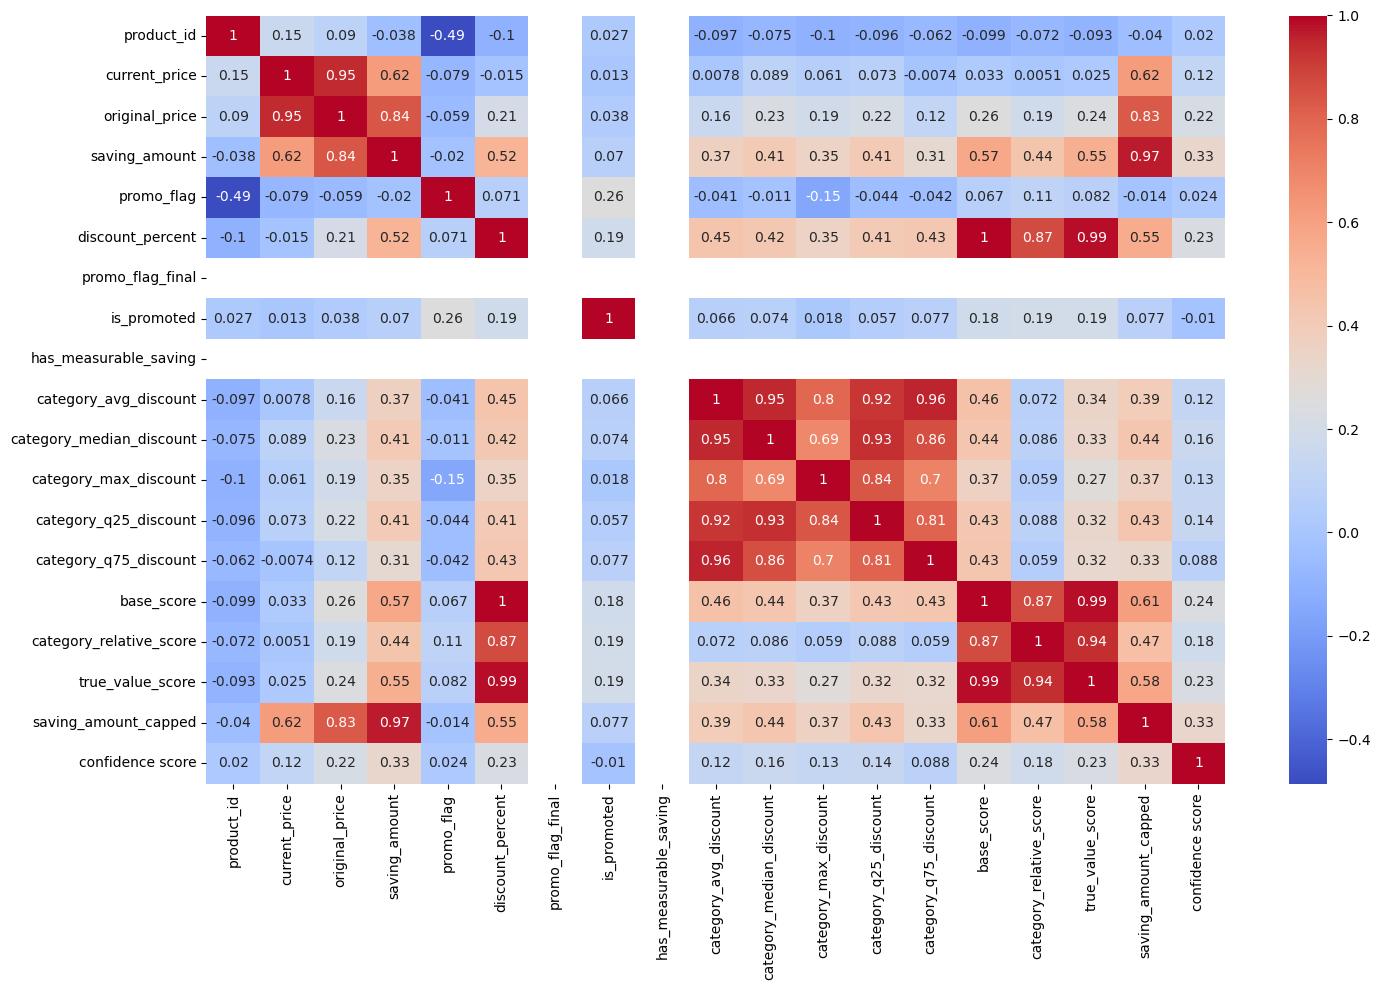

In [24]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, ax=ax, annot=True, cmap="coolwarm")

plt.tight_layout()

In [25]:
user_df.columns

Index(['sessions_count', 'avg_engagement_time_sec', 'pageviews_per_session',
       'compare_ratio', 'specials_ratio', 'mylists_ratio',
       'category_browse_ratio', 'product_detail_ratio', 'unique_pages_visited',
       'browsing_entropy', 'days_since_first_visit',
       'days_since_last_activity', 'user_pseudo_id', 'reporting_window_start',
       'reporting_window_end', 'is_included_in_run', 'label',
       'converted label'],
      dtype='str')

In [26]:
sd = ['sessions_count', 'avg_engagement_time_sec', 'pageviews_per_session',
       'compare_ratio', 'specials_ratio', 'mylists_ratio',
       'category_browse_ratio', 'product_detail_ratio', 'unique_pages_visited',
       'browsing_entropy', 'days_since_first_visit','days_since_last_activity']

In [27]:
len(sd)

12

In [28]:
fg = {0: {}, 1: {}, 2: {}, 3: {}}
for y in fg.keys():
    for s in sd:
        fg[y][s] = [user_df[user_df["converted label"] == y][s].values]
    


In [29]:
fg[0]

{'sessions_count': [array([1, 3, 4, 6, 7, 4, 3, 3, 6, 3, 3, 1, 3, 1, 1, 1, 1, 1, 2, 5, 6, 3,
         1, 4, 1, 5, 8, 6, 6, 6, 8, 3, 7, 1, 5, 7, 6, 3, 4, 1, 3, 6, 4, 5,
         5, 4, 3, 5, 6, 4, 4, 3, 5, 4, 5, 5, 1, 4, 5, 1, 4, 6, 7, 4, 4, 1,
         6, 1, 4, 7, 5, 1, 1, 3, 3, 1, 4, 4, 1, 3, 1, 7, 5, 1, 4, 6, 3, 4,
         7, 5, 3, 3, 1, 3, 4, 3, 1, 1, 4, 2, 4, 1, 1, 1, 1, 2, 1, 1, 4, 5,
         5, 3, 8, 4, 4, 7, 4, 6, 6, 1, 5, 1, 5, 5, 1, 5, 1, 4, 7, 5, 1, 3,
         6, 5, 8, 5, 1, 4, 1, 2, 5, 6, 5, 3, 1, 1, 5, 4, 4, 5, 3, 5, 1, 4,
         5, 2, 8, 4, 1, 2, 1, 3, 4, 5, 4, 5, 2, 2, 1, 5, 2, 6, 4, 1, 4, 6,
         1, 5, 6, 2, 7, 1, 5, 1, 1, 4, 4, 1, 6, 4, 5, 1, 1, 6, 1, 7, 2, 6,
         1, 5, 3, 2, 7, 3, 5, 1, 7, 5, 3, 7, 1, 2, 4, 1, 2, 1, 5, 4, 4, 2,
         3, 7, 7, 5, 6, 1, 1, 3, 3, 1, 5, 6, 7, 5, 4, 1, 1, 6, 3, 7, 7, 4,
         1, 4, 4, 6, 1, 4, 3, 1, 3, 1, 8, 4, 6, 5, 8, 3, 3, 3, 1, 1, 1, 1,
         5, 4, 1, 7, 5, 3, 1, 3, 5, 4, 1, 2, 3, 1, 6, 4, 4, 1, 1, 5, 1, 4,
       

## how the different labels has different variance in the dataset

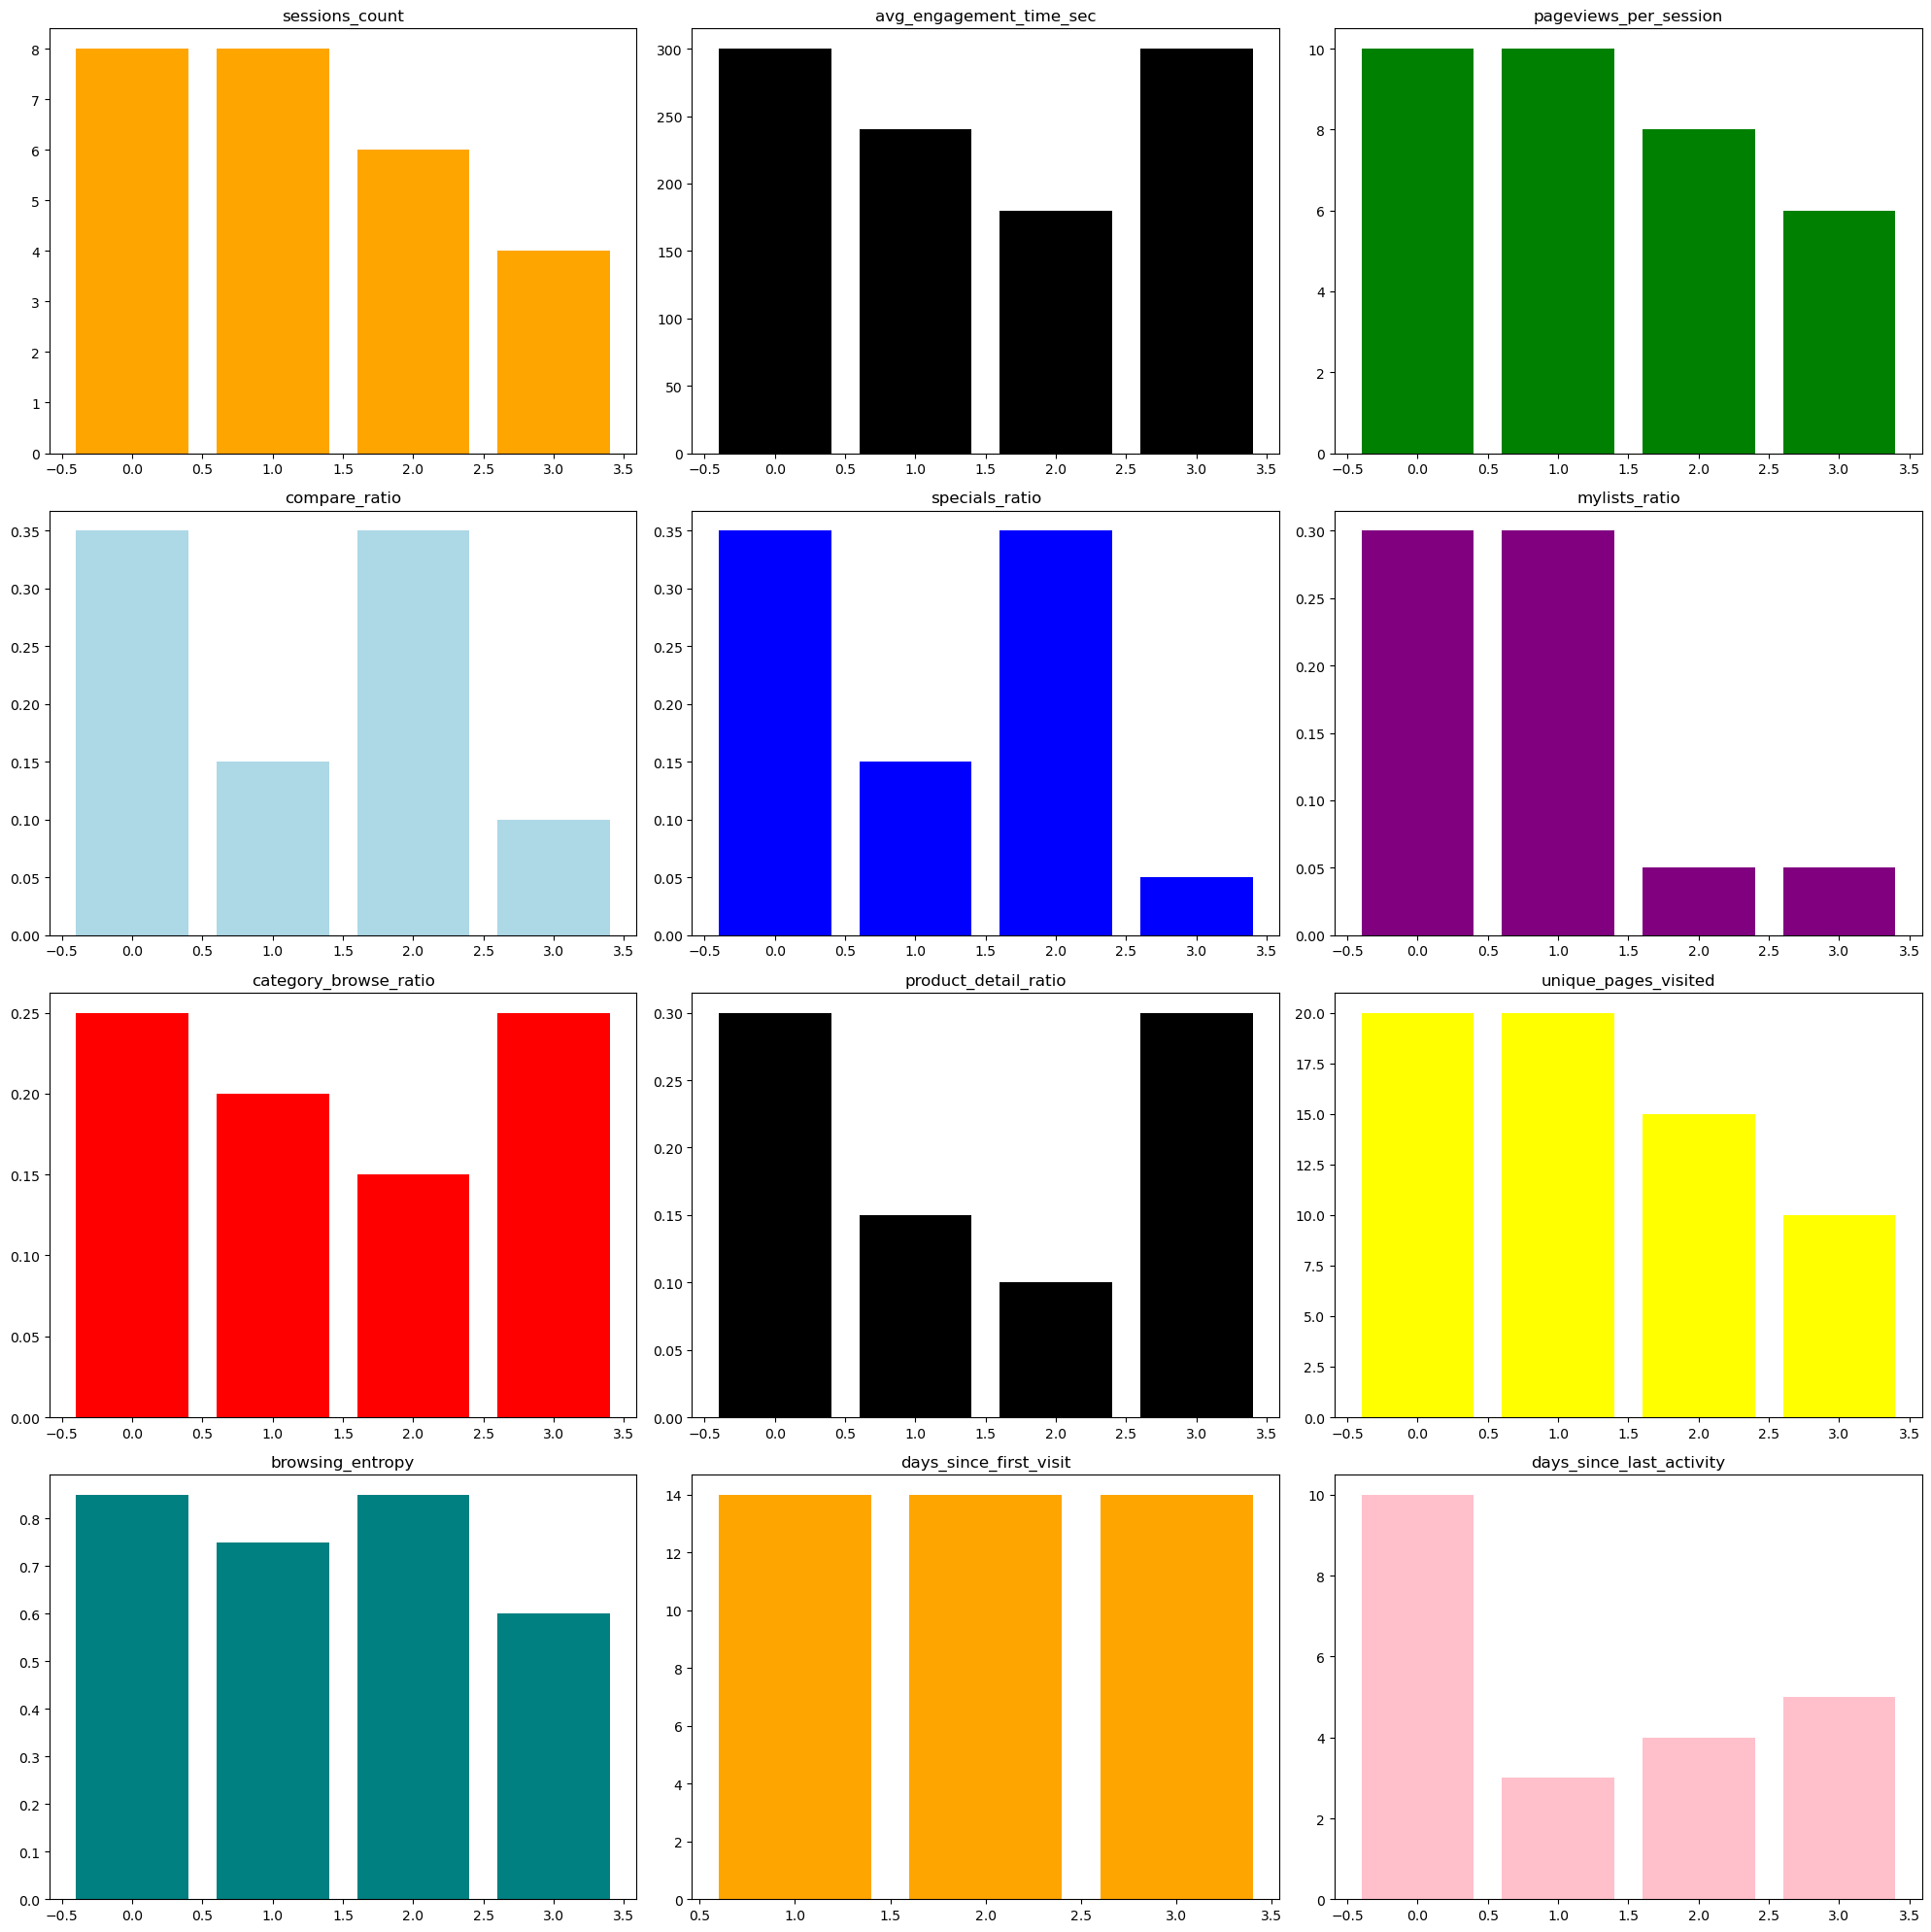

In [30]:
fig, axs = plt.subplots(4, 3, figsize = (20,20))
axs = axs.flatten()
for ax, title, c in zip(axs, user_df.columns, ["orange", "black", "green", 'lightblue', 'blue', 'purple', 'red', 'black', 
                                              'yellow', 'teal', 'orange','pink']):
    data = {}
    for i in list(fg.keys()):
        data[i] = fg[i][title]
    k = list(data.keys())
    v = [data[j][0].max() for j in k]
    
    ax.bar(k, v, color = c)
    ax.set_title(title)
plt.tight_layout()
plt.show()
    


In [31]:
x_train, x_test, y_train, y_test = train_test_split(
    user_df[sd],
    user_df["converted label"],
    test_size=0.25,
    random_state=42
)
scaler = StandardScaler()

x_train_tr = scaler.fit_transform(x_train)
x_test_tr = scaler.transform(x_test)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("mlp", MLPClassifier(
        max_iter=100,
        random_state=42,
        hidden_layer_sizes=(150,)
    ))
])

model.fit(x_train_tr, y_train)

r = permutation_importance(
    model,
    x_test_tr,
    y_test,
    n_repeats=30,
    random_state=0
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


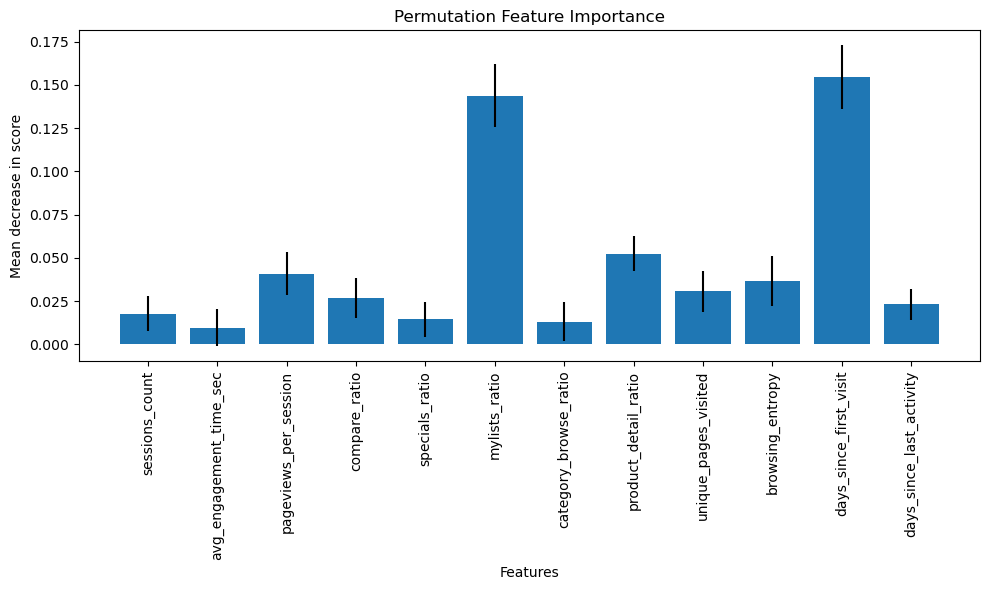

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    sd,
    r.importances_mean,
    yerr=r.importances_std
)

plt.xticks(rotation=90)
plt.ylabel("Mean decrease in score")
plt.xlabel("Features")
plt.title("Permutation Feature Importance")

plt.tight_layout()
plt.show()

Seem like the features contribue to prediction in various scale. 

## 2. The machine learning hyperparameters to choose the best model 

In [33]:

def ml(x_train, x_test, y_train, y_test,
       hidden_layer_sizes=(100,),
       learning_rate_init=0.001):

    # Impute missing values
    imputer = SimpleImputer(strategy="median")

    x_train_imp = imputer.fit_transform(x_train)
    x_test_imp = imputer.transform(x_test)

    # Standardise
    scaler = StandardScaler()

    x_train_tr = scaler.fit_transform(x_train_imp)
    x_test_tr = scaler.transform(x_test_imp)

    # Model
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        max_iter=500,
        random_state=42
    )

    # IMPORTANT: y_train, not x_train
    model.fit(x_train_tr, y_train)

    # Training loss
    tloss = model.loss_curve_
    
    # Training accuracy
    train_accuracy = model.score(x_train_tr, y_train)
    
    # Predictions on test/validation data
    preds = model.predict(x_test_tr)
    
    # Test accuracy
    test_accuracy = model.score(x_test_tr, y_test)
    
    return tloss, preds, train_accuracy, test_accuracy


In [34]:
ls = [(100,), (150,), (200,)]
qs = []
we = []
re = []
rt = []
for z in ls:
    df, fg, tr, uy = ml(x_train, x_test, y_train, y_test, hidden_layer_sizes = z)
    qs.append(df)
    we.append(fg)
    re.append(tr)
    rt.append(uy)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


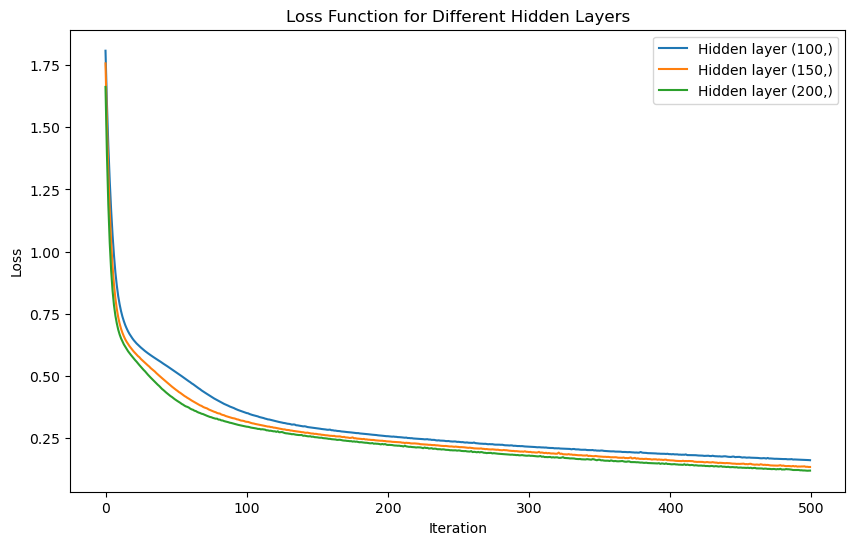

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

for z, loss in zip(ls, qs):
    ax.plot(loss, label=f"Hidden layer {z}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Loss Function for Different Hidden Layers")
ax.legend()

plt.show()

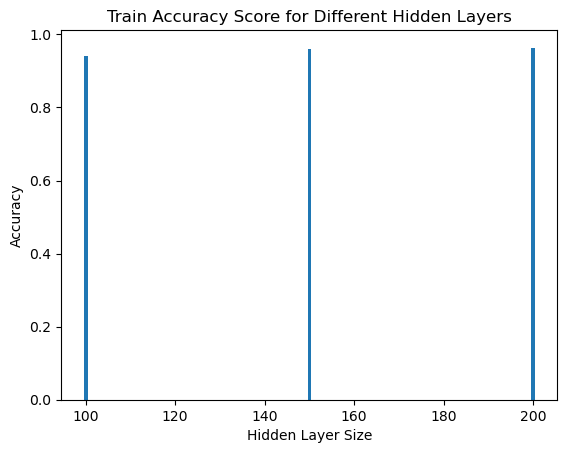

In [36]:
plt.bar([z[0] for z in ls], re)

plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy")
plt.title("Train Accuracy Score for Different Hidden Layers")

plt.show()


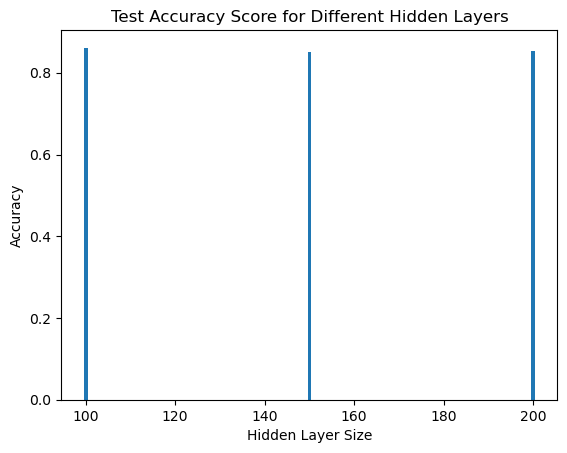

In [37]:
plt.bar([z[0] for z in ls], rt)

plt.xlabel("Hidden Layer Size")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Score for Different Hidden Layers")

plt.show()


Despite hidden class (100,) has the highest loss function. 
It has the best accuracy score so I chose it. 

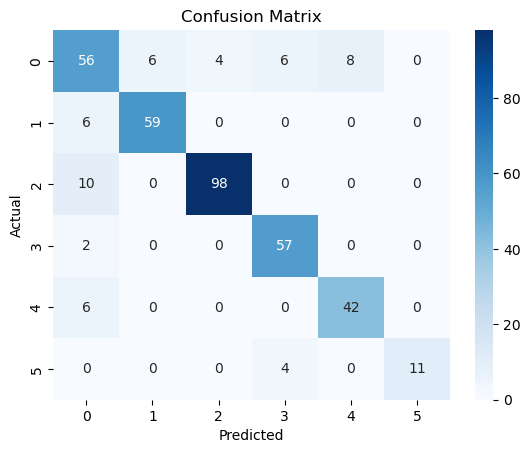

In [38]:
cm = confusion_matrix(y_test, we[0])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
lrs = [1e-3, 0.0025, 0.005, 0.0075]
kl = []
jk = []
hj = []
ga = []
for f in lrs:
    tloss, preds, train_accuracy, test_accuracy = ml(x_train, x_test, y_train, y_test, learning_rate_init = f)
    kl.append(tloss)
    jk.append(preds)
    hj.append(train_accuracy)
    ga.append(test_accuracy)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [155]:
hj

[0.9413333333333334,
 0.9786666666666667,
 0.9777777777777777,
 0.9662222222222222]

In [156]:
ga

[0.8613333333333333, 0.8426666666666667, 0.856, 0.84]

I chose hidden state (100,) and learning rate at 10*(-3) for the model. 

In [157]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("mlp", MLPClassifier(
        max_iter=100,
        random_state=42,
        hidden_layer_sizes=(100,)
    ))
])

## 3. Now we are developing the method to calculate the archetypes of custumer from the df. 

#### As there are some columns that has string values I convert them to norminal data.

In [84]:
df['brand'].unique()

<ArrowStringArray>
[                  'Coles',                 'Cadbury',
                   'Nivea',                 'Colgate',
                 'L'Oreal',                 'L'oreal',
      'L'Oreal Telescopic',           'L'Oreal Paris',
      'L'Oreal Excellence', 'L'Oreal Elvive Hyaluron',
 ...
                     '7Up',                'Roa Boat',
         'Catalina Sounds',            'Secret Stone',
                  'Samboy',            'French Fries',
                 'Jumpy's',                  'Sakata',
                 'Celsius',            'James Squire']
Length: 713, dtype: str

In [85]:
wr = np.arange(0, 713, 1)
gz = list(df['brand'].unique())
hj = {}
for n in range(len(gz)):
    hj[gz[n]] = int(wr[n])
df['converted brand'] = df['brand'].map(hj)
df

,retailer,product_id,product_name,brand,size,current_price,original_price,saving_amount,unit_price_text,promo_flag,...,category_max_discount,category_q25_discount,category_q75_discount,base_score,category_relative_score,true_value_score,discount_class,saving_amount_capped,discount_class_v2,converted brand
0,Coles,8.781518e+06,Regular Pork Mince,Coles,500g,5.50,6.50,1.00,$11.00/ 1kg,0.0,...,39.39,10.3950,18.6050,12.50,10,22.50,OK Discount,1.00,OK Discount,0
1,Coles,1.546564e+06,Tasmanian Salmon Portions Skin On 4 Pack,Coles,460g,17.50,19.50,2.00,$38.04/ 1kg,0.0,...,39.39,10.3950,18.6050,8.61,0,8.61,OK Discount,2.00,OK Discount,0
2,Coles,3.292300e+06,Lamb Loin Chops Bulk,Coles,approx. 890g,23.14,29.37,6.23,$26.00/ 1kg,0.0,...,39.39,10.3950,18.6050,18.21,15,33.21,Good Discount,6.23,Good Discount,0
3,Coles,3.035293e+06,Pork Spare Ribs,Coles,approx. 950g,18.05,20.90,2.85,$19.00/ 1kg,0.0,...,39.39,10.3950,18.6050,11.48,10,21.48,OK Discount,2.85,OK Discount,0
4,Coles,3.745878e+06,RSPCA Approved Chicken Kebabs Honey & Soy,Coles,750g,10.00,11.50,1.50,$13.33/ 1kg,0.0,...,33.33,11.4575,22.2200,10.73,5,15.73,OK Discount,1.50,OK Discount,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,IGA,1.900000e+11,James Squire 150 Lashes Pale Ale Can Wrap,James Squire,NaN,19.00,19.99,0.99,$3.17 each,NaN,...,48.00,9.0100,19.9525,4.16,0,4.16,OK Discount,0.99,OK Discount,712
8993,IGA,5.661100e+04,Carlton Dry Bottles,Carlton,NaN,59.00,66.99,7.99,$2.46 each,NaN,...,48.00,9.0100,19.9525,11.14,5,16.14,OK Discount,7.99,OK Discount,644
8994,IGA,1.900000e+11,Jameson Irish Whiskey Smooth Dry & Lime,Jameson,NaN,134.99,137.00,2.01,$5.62 each,NaN,...,48.00,9.0100,19.9525,1.58,0,1.58,OK Discount,2.01,OK Discount,629
8995,IGA,1.692500e+04,Rockstar Punched Energy & Guava Drink,Rockstar,NaN,3.30,3.95,0.65,$0.66/100ml,NaN,...,50.65,18.8700,40.0000,13.30,0,13.30,OK Discount,0.65,OK Discount,666


In [86]:
df['retailer'].unique()

<ArrowStringArray>
['Coles', 'Woolworths', 'IGA']
Length: 3, dtype: str

In [87]:
ty = np.arange(0, 3, 1)
cb = list(df['retailer'].unique())
aw = {}
for m in range(len(cb)):
    aw[cb[m]] = int(ty[m])
df['converted retailer'] = df['retailer'].map(aw)
df

,retailer,product_id,product_name,brand,size,current_price,original_price,saving_amount,unit_price_text,promo_flag,...,category_q25_discount,category_q75_discount,base_score,category_relative_score,true_value_score,discount_class,saving_amount_capped,discount_class_v2,converted brand,converted retailer
0,Coles,8.781518e+06,Regular Pork Mince,Coles,500g,5.50,6.50,1.00,$11.00/ 1kg,0.0,...,10.3950,18.6050,12.50,10,22.50,OK Discount,1.00,OK Discount,0,0
1,Coles,1.546564e+06,Tasmanian Salmon Portions Skin On 4 Pack,Coles,460g,17.50,19.50,2.00,$38.04/ 1kg,0.0,...,10.3950,18.6050,8.61,0,8.61,OK Discount,2.00,OK Discount,0,0
2,Coles,3.292300e+06,Lamb Loin Chops Bulk,Coles,approx. 890g,23.14,29.37,6.23,$26.00/ 1kg,0.0,...,10.3950,18.6050,18.21,15,33.21,Good Discount,6.23,Good Discount,0,0
3,Coles,3.035293e+06,Pork Spare Ribs,Coles,approx. 950g,18.05,20.90,2.85,$19.00/ 1kg,0.0,...,10.3950,18.6050,11.48,10,21.48,OK Discount,2.85,OK Discount,0,0
4,Coles,3.745878e+06,RSPCA Approved Chicken Kebabs Honey & Soy,Coles,750g,10.00,11.50,1.50,$13.33/ 1kg,0.0,...,11.4575,22.2200,10.73,5,15.73,OK Discount,1.50,OK Discount,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,IGA,1.900000e+11,James Squire 150 Lashes Pale Ale Can Wrap,James Squire,NaN,19.00,19.99,0.99,$3.17 each,NaN,...,9.0100,19.9525,4.16,0,4.16,OK Discount,0.99,OK Discount,712,2
8993,IGA,5.661100e+04,Carlton Dry Bottles,Carlton,NaN,59.00,66.99,7.99,$2.46 each,NaN,...,9.0100,19.9525,11.14,5,16.14,OK Discount,7.99,OK Discount,644,2
8994,IGA,1.900000e+11,Jameson Irish Whiskey Smooth Dry & Lime,Jameson,NaN,134.99,137.00,2.01,$5.62 each,NaN,...,9.0100,19.9525,1.58,0,1.58,OK Discount,2.01,OK Discount,629,2
8995,IGA,1.692500e+04,Rockstar Punched Energy & Guava Drink,Rockstar,NaN,3.30,3.95,0.65,$0.66/100ml,NaN,...,18.8700,40.0000,13.30,0,13.30,OK Discount,0.65,OK Discount,666,2


In [88]:
df.columns

Index(['retailer', 'product_id', 'product_name', 'brand', 'size',
       'current_price', 'original_price', 'saving_amount', 'unit_price_text',
       'promo_flag', 'promotion_type', 'category_group', 'category',
       'subcategory', 'image_url', 'scrape_timestamp', 'discount_percent',
       'promo_flag_final', 'is_promoted', 'has_measurable_saving',
       'raw_main_cat', 'main_category', 'category_avg_discount',
       'category_median_discount', 'category_max_discount',
       'category_q25_discount', 'category_q75_discount', 'base_score',
       'category_relative_score', 'true_value_score', 'discount_class',
       'saving_amount_capped', 'discount_class_v2', 'converted brand',
       'converted retailer'],
      dtype='str')

In [89]:
df['discount_class_v2'].unique()

<ArrowStringArray>
['OK Discount', 'Good Discount', 'Excellent Discount',
 'DiscountMate Recommends']
Length: 4, dtype: str

In [90]:
aq = np.arange(0, 4, 1)
ve = list(df['discount_class_v2'].unique())
uo = {}
for h in range(len(ve)):
    uo[ve[h]] = int(aq[h])
df['converted discount class v2'] = df['discount_class_v2'].map(uo)
df

,retailer,product_id,product_name,brand,size,current_price,original_price,saving_amount,unit_price_text,promo_flag,...,category_q75_discount,base_score,category_relative_score,true_value_score,discount_class,saving_amount_capped,discount_class_v2,converted brand,converted retailer,converted discount class v2
0,Coles,8.781518e+06,Regular Pork Mince,Coles,500g,5.50,6.50,1.00,$11.00/ 1kg,0.0,...,18.6050,12.50,10,22.50,OK Discount,1.00,OK Discount,0,0,0
1,Coles,1.546564e+06,Tasmanian Salmon Portions Skin On 4 Pack,Coles,460g,17.50,19.50,2.00,$38.04/ 1kg,0.0,...,18.6050,8.61,0,8.61,OK Discount,2.00,OK Discount,0,0,0
2,Coles,3.292300e+06,Lamb Loin Chops Bulk,Coles,approx. 890g,23.14,29.37,6.23,$26.00/ 1kg,0.0,...,18.6050,18.21,15,33.21,Good Discount,6.23,Good Discount,0,0,1
3,Coles,3.035293e+06,Pork Spare Ribs,Coles,approx. 950g,18.05,20.90,2.85,$19.00/ 1kg,0.0,...,18.6050,11.48,10,21.48,OK Discount,2.85,OK Discount,0,0,0
4,Coles,3.745878e+06,RSPCA Approved Chicken Kebabs Honey & Soy,Coles,750g,10.00,11.50,1.50,$13.33/ 1kg,0.0,...,22.2200,10.73,5,15.73,OK Discount,1.50,OK Discount,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,IGA,1.900000e+11,James Squire 150 Lashes Pale Ale Can Wrap,James Squire,NaN,19.00,19.99,0.99,$3.17 each,NaN,...,19.9525,4.16,0,4.16,OK Discount,0.99,OK Discount,712,2,0
8993,IGA,5.661100e+04,Carlton Dry Bottles,Carlton,NaN,59.00,66.99,7.99,$2.46 each,NaN,...,19.9525,11.14,5,16.14,OK Discount,7.99,OK Discount,644,2,0
8994,IGA,1.900000e+11,Jameson Irish Whiskey Smooth Dry & Lime,Jameson,NaN,134.99,137.00,2.01,$5.62 each,NaN,...,19.9525,1.58,0,1.58,OK Discount,2.01,OK Discount,629,2,0
8995,IGA,1.692500e+04,Rockstar Punched Energy & Guava Drink,Rockstar,NaN,3.30,3.95,0.65,$0.66/100ml,NaN,...,40.0000,13.30,0,13.30,OK Discount,0.65,OK Discount,666,2,0


In [91]:
fea = ['convert raw main cat', 'has_measurable_saving', 'category_avg_discount',
       'convert promotion type', 'converted brand', 'converted retailer', 'discount_percent',
       'saving_amount_capped', 'true_value_score', 'converted discount class v2', 'category_avg_discount']

In [92]:
maps

{'Low-signal residual': 0,
 'Family Planner': 1,
 'Budget-Conscious Shopper': 2,
 'Health Enthusiast': 3,
 'Convenience Seeker': 4,
 'Premium Shopper': 5}

In [93]:
df['discount_percent'].describe()

count    8997.000000
mean       31.661880
std        14.091388
min         0.010000
25%        20.000000
50%        30.000000
75%        50.000000
max        80.000000
Name: discount_percent, dtype: float64

In [94]:
df['raw_main_cat'].unique()

<ArrowStringArray>
[                'PORK/HAMS/BACON',                         'SEAFOOD',
                            'LAMB',                     'VALUE ADDED',
                       'BEEF/VEAL',                           'DAIRY',
                         'POULTRY',              'BAKERY CAKES/YEAST',
                         'IMPULSE',                  'MEAL SOLUTIONS',
             'HEALTH  BEAUTY BABY',                       'HOME CARE',
             'GENERAL MERCHANDISE',            'IN-STORE BH/BOUTIQUE',
                          'LIQUOR',                   'BASIC APPAREL',
               'APPAREL OUTERWEAR',                           'FRUIT',
              'SMALLGOODS/POULTRY',                   'CONFECTIONERY',
                  'SEASONAL FOODS',                      'TOILETRIES',
                  'PREPARED FOODS',                      'CONDIMENTS',
                   'COOKING NEEDS',                       'CLEANSING',
                     'HEALTH CARE',         'GARDEN AIDS/S

In [95]:
fh = list(df['raw_main_cat'].unique())

In [96]:
o = np.arange(0,87,1)

p = {}
for d in range(len(fh)):
    p[fh[d]] = int(o[d])

In [97]:
df["convert raw main cat"] = df['raw_main_cat'].map(p)

In [98]:
df

,retailer,product_id,product_name,brand,size,current_price,original_price,saving_amount,unit_price_text,promo_flag,...,base_score,category_relative_score,true_value_score,discount_class,saving_amount_capped,discount_class_v2,converted brand,converted retailer,converted discount class v2,convert raw main cat
0,Coles,8.781518e+06,Regular Pork Mince,Coles,500g,5.50,6.50,1.00,$11.00/ 1kg,0.0,...,12.50,10,22.50,OK Discount,1.00,OK Discount,0,0,0,0
1,Coles,1.546564e+06,Tasmanian Salmon Portions Skin On 4 Pack,Coles,460g,17.50,19.50,2.00,$38.04/ 1kg,0.0,...,8.61,0,8.61,OK Discount,2.00,OK Discount,0,0,0,1
2,Coles,3.292300e+06,Lamb Loin Chops Bulk,Coles,approx. 890g,23.14,29.37,6.23,$26.00/ 1kg,0.0,...,18.21,15,33.21,Good Discount,6.23,Good Discount,0,0,1,2
3,Coles,3.035293e+06,Pork Spare Ribs,Coles,approx. 950g,18.05,20.90,2.85,$19.00/ 1kg,0.0,...,11.48,10,21.48,OK Discount,2.85,OK Discount,0,0,0,0
4,Coles,3.745878e+06,RSPCA Approved Chicken Kebabs Honey & Soy,Coles,750g,10.00,11.50,1.50,$13.33/ 1kg,0.0,...,10.73,5,15.73,OK Discount,1.50,OK Discount,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,IGA,1.900000e+11,James Squire 150 Lashes Pale Ale Can Wrap,James Squire,NaN,19.00,19.99,0.99,$3.17 each,NaN,...,4.16,0,4.16,OK Discount,0.99,OK Discount,712,2,0,70
8993,IGA,5.661100e+04,Carlton Dry Bottles,Carlton,NaN,59.00,66.99,7.99,$2.46 each,NaN,...,11.14,5,16.14,OK Discount,7.99,OK Discount,644,2,0,70
8994,IGA,1.900000e+11,Jameson Irish Whiskey Smooth Dry & Lime,Jameson,NaN,134.99,137.00,2.01,$5.62 each,NaN,...,1.58,0,1.58,OK Discount,2.01,OK Discount,629,2,0,73
8995,IGA,1.692500e+04,Rockstar Punched Energy & Guava Drink,Rockstar,NaN,3.30,3.95,0.65,$0.66/100ml,NaN,...,13.30,0,13.30,OK Discount,0.65,OK Discount,666,2,0,76


In [99]:
df['promotion_type'].unique()

<ArrowStringArray>
['SPECIAL', 'DOWNDOWN', nan, 'NOT_SET', 'tpr']
Length: 5, dtype: str

In [100]:
e = {'SPECIAL': 0, 'DOWNDOWN': 1, 'NOT_SET': 2, 'tpr':3}
df["convert promotion type"] = df['promotion_type'].map(e)
df

,retailer,product_id,product_name,brand,size,current_price,original_price,saving_amount,unit_price_text,promo_flag,...,category_relative_score,true_value_score,discount_class,saving_amount_capped,discount_class_v2,converted brand,converted retailer,converted discount class v2,convert raw main cat,convert promotion type
0,Coles,8.781518e+06,Regular Pork Mince,Coles,500g,5.50,6.50,1.00,$11.00/ 1kg,0.0,...,10,22.50,OK Discount,1.00,OK Discount,0,0,0,0,0.0
1,Coles,1.546564e+06,Tasmanian Salmon Portions Skin On 4 Pack,Coles,460g,17.50,19.50,2.00,$38.04/ 1kg,0.0,...,0,8.61,OK Discount,2.00,OK Discount,0,0,0,1,0.0
2,Coles,3.292300e+06,Lamb Loin Chops Bulk,Coles,approx. 890g,23.14,29.37,6.23,$26.00/ 1kg,0.0,...,15,33.21,Good Discount,6.23,Good Discount,0,0,1,2,0.0
3,Coles,3.035293e+06,Pork Spare Ribs,Coles,approx. 950g,18.05,20.90,2.85,$19.00/ 1kg,0.0,...,10,21.48,OK Discount,2.85,OK Discount,0,0,0,0,1.0
4,Coles,3.745878e+06,RSPCA Approved Chicken Kebabs Honey & Soy,Coles,750g,10.00,11.50,1.50,$13.33/ 1kg,0.0,...,5,15.73,OK Discount,1.50,OK Discount,0,0,0,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,IGA,1.900000e+11,James Squire 150 Lashes Pale Ale Can Wrap,James Squire,NaN,19.00,19.99,0.99,$3.17 each,NaN,...,0,4.16,OK Discount,0.99,OK Discount,712,2,0,70,3.0
8993,IGA,5.661100e+04,Carlton Dry Bottles,Carlton,NaN,59.00,66.99,7.99,$2.46 each,NaN,...,5,16.14,OK Discount,7.99,OK Discount,644,2,0,70,3.0
8994,IGA,1.900000e+11,Jameson Irish Whiskey Smooth Dry & Lime,Jameson,NaN,134.99,137.00,2.01,$5.62 each,NaN,...,0,1.58,OK Discount,2.01,OK Discount,629,2,0,73,3.0
8995,IGA,1.692500e+04,Rockstar Punched Energy & Guava Drink,Rockstar,NaN,3.30,3.95,0.65,$0.66/100ml,NaN,...,0,13.30,OK Discount,0.65,OK Discount,666,2,0,76,3.0


### I want to cluster the data into 6 groups that can predict different behaviours from the archetypes.
### But the problem is I don't have a data like that.
### And the solution is using unsupervised ml, kmeans. 
### But there is no gurantee that the group are correct. 

This is the kmeans classes 

In [101]:
X = df[fea]

# Replace missing values
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# K-Means with 5 clusters
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

In [102]:
df['labels'] = labels

In [103]:
df['labels'].unique()

array([2, 4, 3, 1, 0, 5], dtype=int32)

##### Added the column labels to the df as the target. And later we will want the target into the data set when we make a copy of the df. 

In [104]:
fea.append('labels')

In [105]:
data = df[fea]

In [106]:
data

,convert raw main cat,has_measurable_saving,category_avg_discount,convert promotion type,converted brand,converted retailer,discount_percent,saving_amount_capped,true_value_score,converted discount class v2,category_avg_discount,labels
0,0,1,16.378889,0.0,0,0,15.38,1.00,22.50,0,16.378889,2
1,1,1,16.378889,0.0,0,0,10.26,2.00,8.61,0,16.378889,2
2,2,1,16.378889,0.0,0,0,21.21,6.23,33.21,1,16.378889,2
3,0,1,16.378889,1.0,0,0,13.64,2.85,21.48,0,16.378889,2
4,3,1,18.130000,1.0,0,0,13.04,1.50,15.73,0,18.130000,2
...,...,...,...,...,...,...,...,...,...,...,...,...
8992,70,1,14.499219,3.0,712,2,4.95,0.99,4.16,0,14.499219,5
8993,70,1,14.499219,3.0,644,2,11.93,7.99,16.14,0,14.499219,5
8994,73,1,14.499219,3.0,629,2,1.47,2.01,1.58,0,14.499219,5
8995,76,1,28.966295,3.0,666,2,16.46,0.65,13.30,0,28.966295,5


/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


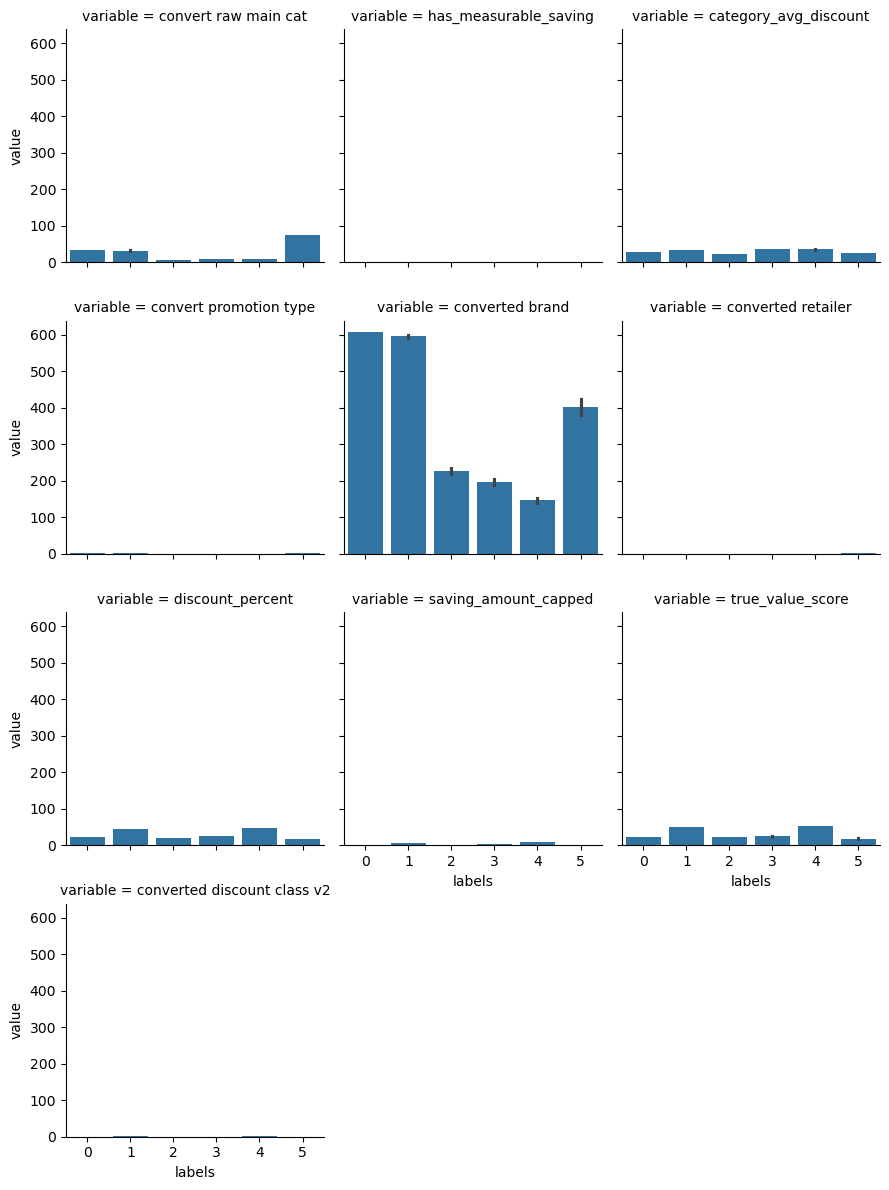

In [107]:
data_long = data.melt(
    id_vars="labels",
    var_name="variable",
    value_name="value"
)

g = sns.FacetGrid(data_long, col="variable", col_wrap=3)
g.map(sns.barplot, "labels", "value")
plt.show()

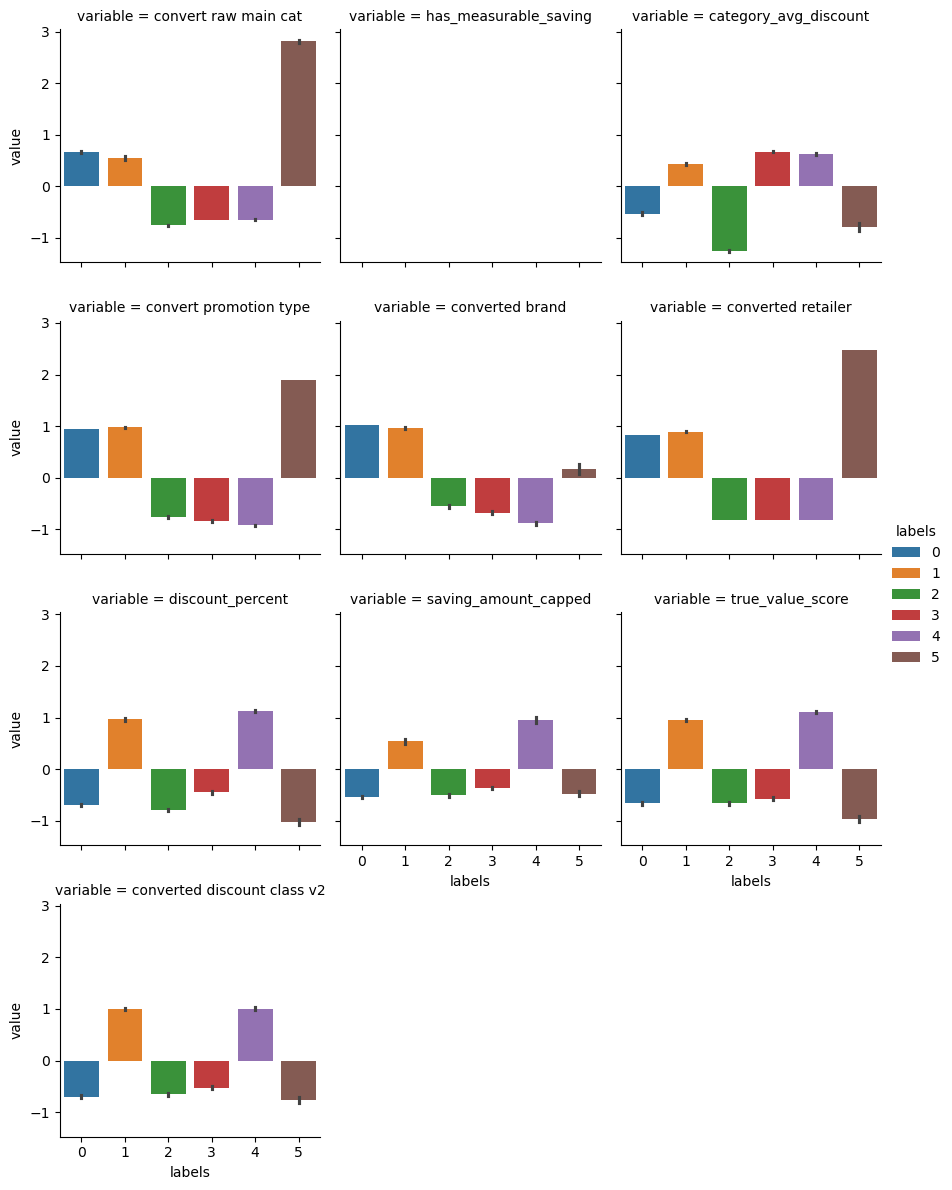

In [108]:
scaled_data = scaler.fit_transform(data)

scaled_data = pd.DataFrame(
    scaled_data,
    columns=data.columns,
    index=data.index
)

scaled_data["labels"] = labels

scaled_data_long = scaled_data.melt(
    id_vars="labels",
    var_name="variable",
    value_name="value"
)

g = sns.FacetGrid(
    scaled_data_long,
    col="variable",
    col_wrap=3, hue="labels"
)

g.map_dataframe(sns.barplot, x="labels", y="value")
g.add_legend()

In [112]:
data[data['labels'] == 0]['convert raw main cat'].describe()

count    1737.000000
mean       34.338515
std        11.225972
min        19.000000
25%        25.000000
50%        32.000000
75%        44.000000
max        64.000000
Name: convert raw main cat, dtype: float64

In [111]:
p

{'PORK/HAMS/BACON': 0,
 'SEAFOOD': 1,
 'LAMB': 2,
 'VALUE ADDED': 3,
 'BEEF/VEAL': 4,
 'DAIRY': 5,
 'POULTRY': 6,
 'BAKERY CAKES/YEAST': 7,
 'IMPULSE': 8,
 'MEAL SOLUTIONS': 9,
 'HEALTH  BEAUTY BABY': 10,
 'HOME CARE': 11,
 'GENERAL MERCHANDISE': 12,
 'IN-STORE BH/BOUTIQUE': 13,
 'LIQUOR': 14,
 'BASIC APPAREL': 15,
 'APPAREL OUTERWEAR': 16,
 'FRUIT': 17,
 'SMALLGOODS/POULTRY': 18,
 'CONFECTIONERY': 19,
 'SEASONAL FOODS': 20,
 'TOILETRIES': 21,
 'PREPARED FOODS': 22,
 'CONDIMENTS': 23,
 'COOKING NEEDS': 24,
 'CLEANSING': 25,
 'HEALTH CARE': 26,
 'GARDEN AIDS/SEEDS/BULBS': 27,
 'BISCUITS': 28,
 'HEALTH FOODS': 29,
 'CHEESE EVERYDAY': 30,
 'BREAKFAST FOODS': 31,
 'BABY NEEDS': 32,
 'LONGLIFE JUICE / DRINKS': 33,
 'CORDIAL / DRINK BASES': 34,
 'BEVERAGES': 35,
 'ETHNIC / GOURMET FOOD': 36,
 'DELI CONVENIENCE': 37,
 'SNACKS': 38,
 'INSTORE BAKERY': 39,
 'PROPRIETARY BAKERY': 40,
 'FROZEN MEALS': 41,
 'FREEZER - FISH': 42,
 'CANNED FISH': 43,
 'JAMS / SPREADS': 44,
 'PASTA / RICE': 45,
 'ICE

In [113]:
data[data['labels'] == 4]['convert raw main cat'].describe()

count    1706.000000
mean        9.714537
std         1.518214
min         5.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        16.000000
Name: convert raw main cat, dtype: float64

In [114]:
data[data['labels'] == 1]['convert raw main cat'].describe()

count    1798.000000
mean       32.130145
std        14.691514
min        19.000000
25%        21.000000
50%        26.000000
75%        43.000000
max        84.000000
Name: convert raw main cat, dtype: float64

In [115]:
data[data['labels'] == 5]['convert raw main cat'].describe()

count    449.000000
mean      74.599109
std        6.035949
min       65.000000
25%       69.000000
50%       75.000000
75%       80.000000
max       86.000000
Name: convert raw main cat, dtype: float64

Now look at the different main category of each class to decide which class the df labels match with the true class in user_df (I had my doubt if this work at first, but it did work). 

Stating with class 'Family planner', represented as 1 in user_df, we check class 0 in df first. 50% buys category 32, Baby Need, 75% buy cat 44, 'Jam/Spread', 25% buy cat 25, cleasning, and categories 64 ('VEG / FRESHCUTS / HARD PRODUCE') and 19 ('CONFECTIONERY'). I think for family planner the aspect also about the size, class 0 has positive promotion type and positive brand may be they are sensitive with healthy choice. I temporary map class 0 in df to class 1 in user df, 'Family planner'.

class 'Health Enthusiast' class 3 in user_df, we check class 4 in df. 50% buys cat 10th, 'HEALTH  BEAUTY BABY'. 75% buys 10, 'HEALTH  BEAUTY BABY'. 25% buy cat 9th, 'MEAL SOLUTIONS'. and there are also cats 16th, 'APPAREL OUTERWEAR', 5th, 'DAIRY'. Seem health for me so I map class 3 in user_df to class 4 in df.

class 'Budget-Conscious Shopper', class 2 in user_df, we check class 1 in df. for this one I think we check the promotion type, saving ammount, brand and retail, convert this discount class and so on. And we have 2 candidates class 1 and class 5 but on converted discount class, discount type, saving amount, avg saving amount class 5 is all negative so we map class 2 in user_df to class 1 in df. 

class 'Premium Shopper', class 5 in user_df. We expect negative discount class, promotion type, avg saving amount on cat, to be low. which we have class 2 and 3. But 3 is more negative to we assocciate class 5 in user_df to class 3. 

class 'Convenience Seeker', class 4 in user_df, we check class 5 in df. 50% buys cat 75 ('Potato Chips' {Um, pretty convinient for me}). 75% buys cat cat 80th, 'Nuts and Jerky'. and cats 86th ('Ready to Eat Meals'), 65th ('Dips and Pate'), 69th ('Chocolate Share Packs'). We associate class 4 in user_df with class 5 in df. 

Don't worry I check the combination multiple times before decided on the label and this is only the summary of it. So the labels was checked multiple times before decision.

In [116]:
maps

{'Low-signal residual': 0,
 'Family Planner': 1,
 'Budget-Conscious Shopper': 2,
 'Health Enthusiast': 3,
 'Convenience Seeker': 4,
 'Premium Shopper': 5}

## 4. This is when I match the labels in df which the correct definition in user_df. And the ML model to take the data and predict the label

In [250]:
true_label = {0:1, 4:3, 5:4, 1:2, 2:0, 3:5}
df['labels'] = df['labels'].map(true_label)

In [251]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

In [255]:
fea

['convert raw main cat',
 'has_measurable_saving',
 'category_avg_discount',
 'convert promotion type',
 'converted brand',
 'converted retailer',
 'discount_percent',
 'saving_amount_capped',
 'true_value_score',
 'converted discount class v2',
 'category_avg_discount',
 'labels']

In [269]:
mv = ['convert raw main cat',
 'has_measurable_saving',
 'category_avg_discount',
 'convert promotion type',
 'converted brand',
 'converted retailer',
 'discount_percent',
 'saving_amount_capped',
 'true_value_score',
 'converted discount class v2',
 'category_avg_discount']
x = df[mv]
X_imp = imputer.fit_transform(x)
    
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
x_train, x_test, y_train, y_test = train_test_split(X_scaled, df['labels'], test_size=0.4, random_state=42)
model.fit(x_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

In [270]:
preds = model.predict(x_test)
accuracy_score(y_test, preds)

0.9983328702417338

almost 100% true correct may be overfitting. 

## 5. This is the final functions

In [117]:
def convert_str(df, column):
    k = list(df[column].unique())
    n = np.arange(0, len(k), 1)
    
    res = {}
    for i in range(len(k)):
        res[k[i]] = int(n[i])
    return res

In [1]:
def persona_score(df, data = None):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("mlp", MLPClassifier(
            max_iter=100,
            random_state=42,
            hidden_layer_sizes=(100,)
        ))
    ])

    fea = [
        'convert raw main cat',
        'has_measurable_saving',
        'category_avg_discount',
        'convert promotion type',
        'converted brand',
        'converted retailer',
        'discount_percent',
        'saving_amount_capped',
        'true_value_score',
        'converted discount class v2'
    ]
    
    """ Some columns have string value and can't be feed into model
        So I convert them into numeric value in norminal data order
        P/S: I know promotion_type is ordinal but I can't find the document so I trested it as norminal.
             If you have resource, plz fix.
    """
    # The example of converting string column into numeric column
    # maps = convert_str(df, "raw_main_cat")
    # df["convert raw main cat"] = df["raw_main_cat"].map(maps)


    X = df[fea]

    # Replace missing values
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X)

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    # Convert back to DataFrame
    X_scaled = pd.DataFrame(
        X_scaled,
        index=df.index,
        columns=fea
    )

    # K-Means with 6 clusters
    kmeans = KMeans(
        n_clusters=6,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # Map K-Means cluster numbers to your desired persona labels
    true_label = {
        0: 1,
        4: 3,
        5: 4,
        1: 2,
        2: 0,
        3: 5
    }

    df['labels'] = labels
    y = df['labels'].map(true_label)

    print(X_scaled.head())
    print(y.head())

    
    # Train MLP
    model.fit(X_scaled, y)

    # Predict
    if data is not None:
        data_imp = imputer.transform(data[features])
        data_scaled = scaler.transform(data_imp)

        preds = model.predict(data_scaled)
    else:
        preds = None


    return model, preds
